# Tytuł projektu

## Wykorzystane biblioteki
1. Scikit - *Wykorzystanie gotowych funkcji (DCT) | Wczytywanie obrazów*
2. Matplotlib - *Tworzenie wykresów*
3. Numpy - *Obliczenia | Matematyka macierzowa*

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import skimage.io as io
import numpy as np
import skimage.color as color
from scipy.fftpack import dct, idct

#### Zmienna definiująca wymiary macierzy kwadratowej
##### Odpowiada za wielkość pojedynczego bloku 

In [16]:
matrix_size = 8

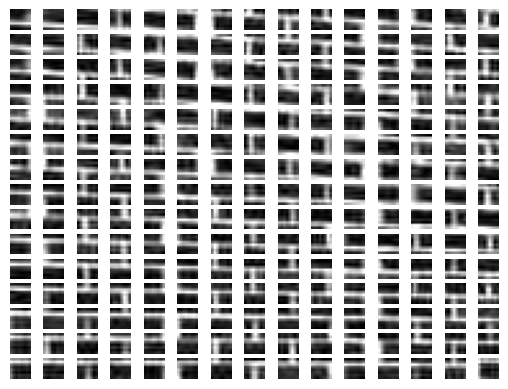

<class 'numpy.ndarray'>
(600, 800)


In [17]:
path = "test_model.jpg"
image = io.imread(path)
image = color.rgb2gray(image)

def crop_image(image, crop_size):
  h, w = image.shape
  new_h = (h // crop_size) * crop_size
  new_w = (w // crop_size) * crop_size
  return image[:new_h, :new_w]

image = crop_image(image, matrix_size)

def splint_to_bloks(image, block_size):
  h, w = image.shape
  splited = np.reshape(image, (h // block_size, block_size, w // block_size, block_size))
  splited = np.transpose(splited,(0,2,1,3))
  return splited

img = splint_to_bloks(image, matrix_size)

#wyświetlenie fragmnetu obrazu z podziałem na bloki
for i in range(15):
  for j in range(15):
    plt.subplot(15, 15, i*15 + j + 1)
    plt.imshow(img[i,j], cmap='gray')
    plt.axis('off')
matplotlib.pyplot.imshow(img[15,0], cmap='gray')
2442

matplotlib.pyplot.show()
print(type(image))
print(image.shape)

In [19]:
img_h = np.shape(img)[0]
img_w = np.shape(img)[1]

def dct_compression(img, img_h, img_w):
 with np.printoptions(edgeitems=8, precision=2, linewidth=1000):
  
  img_block = img[img_h, img_w]

  M = img_block.shape[0]
  N = img_block.shape[1]
  PI = np.pi

  alfa_p = np.full((M, 1), np.sqrt(2/M))
  alfa_q = np.full((1, N), np.sqrt(2/N))
  alfa_p[0, 0] = 1/np.sqrt(M)
  alfa_q[0, 0] = 1/np.sqrt(N)

  m=np.arange(M)
  p=np.arange(M)
  m=np.reshape(m, (1, -1))
  p=np.reshape(p, (-1, 1))
  T = np.cos((PI * (2*m+1) * p) / (2*M))

  T[0, :] /= np.sqrt(M)         
  T[1:, :] /= np.sqrt(M / 2)
 
  B = (T @ img_block @ T.T)

  if(img_h==0 and img_w==0):
    print(B)
  
  mask_size = M//2
  mask = np.zeros((M,N))
  for i in range (0, mask_size):
    for j in range(mask_size-i):
      mask[i, j] = 1
  
  B_masked = B * mask

  A_compressed = T.T @ B_masked @ T
  return A_compressed

img_compressed = np.zeros_like(img)

for i in range(img_h):
   for j in range(img_w):
    block = dct_compression(img, i, j)
    img_compressed[i, j] = block 

[[ 4.08e+00 -1.94e-01  1.05e-01 -2.12e-02 -2.19e-04  1.86e-03 -5.21e-04  6.85e-04]
 [-1.87e-01 -4.19e-02  4.59e-02 -3.15e-02 -5.49e-04  5.72e-04 -1.15e-03 -8.24e-04]
 [-3.13e-01  2.91e-02 -4.39e-02 -1.43e-03 -3.04e-03 -7.28e-04 -1.00e-03 -1.61e-03]
 [ 3.43e-01  5.47e-02 -3.46e-02  2.62e-04 -1.16e-03  6.68e-04  5.43e-04 -1.48e-03]
 [-1.66e-01  3.59e-02  6.43e-04  9.07e-04 -1.55e-03 -8.43e-04 -2.84e-03 -3.37e-04]
 [-4.20e-02 -5.71e-02 -3.33e-04  7.00e-04 -2.95e-03 -9.90e-05  5.91e-04  2.15e-03]
 [ 1.55e-01  2.24e-03 -3.83e-04 -1.04e-03 -2.61e-03 -1.17e-03  4.96e-04 -9.54e-04]
 [-1.11e-01 -1.35e-03 -5.54e-04  4.38e-04 -3.77e-03 -1.45e-03  1.69e-04  2.96e-03]]


In [ ]:
img_compressed = np.zeros_like(img)

for i in range(img_h):
   for j in range(img_w):
    block = dct_compression(img, i, j)
    img_compressed[i, j] = block 